In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import tarfile
import urllib.request
import matplotlib.pyplot as plt

In [2]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents= True, exist_ok= True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

In [3]:
housing_full = load_housing_data()

In [4]:
housing_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Recap: what `info()`, `describe()`, and `head()` just told us

- **`info()`**: 20,640 rows, 10 columns. Every column is numeric except `ocean_proximity` (an `object`, i.e. categorical text). `total_bedrooms` has only 20,433 non-null values → **207 missing values**, which we'll have to impute before feeding this to a model.
- **`describe()`**: summary stats, numeric columns only. Two things worth noticing for the exam:
  - `median_income` ranges ~0.5–15, not real dollars — it's been scaled (tens of thousands of dollars) and **capped** at 15.
  - `median_house_value` maxes out at exactly 500,001 → it's been **capped/censored** at $500,000. That's a real problem if it's our regression target, since the model can never learn to predict above the cap.
- **`head()`**: confirms units/meaning of each column at a glance (e.g. `ocean_proximity` values like `NEAR BAY`).

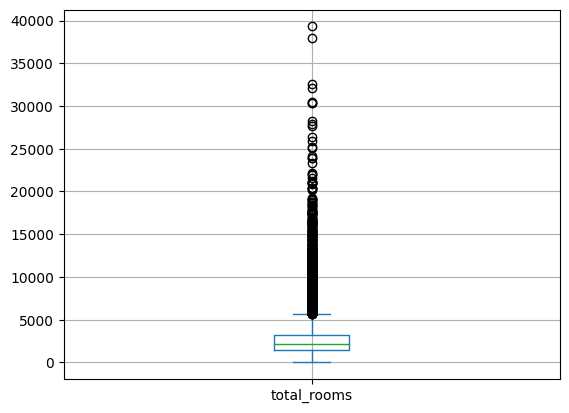

In [7]:
housing_full[["total_rooms"]].plot(kind='box', grid=True)
plt.show()

**Bug fix note:** `df.plot(kind='box', x='total_rooms')` doesn't do what you'd expect. I checked pandas' actual behavior: for `kind='box'`, `x` is *not* used to pick which column to plot — instead it boxed **every other** numeric column (`longitude`, `latitude`, ..., `median_house_value`), leaving `total_rooms` itself out, all crammed onto one axes with wildly different scales (`median_house_value` up to 500,001 vs. `latitude` around 32–42). That's why the output was a giant, unreadable plot. Selecting the single column first — `housing_full[["total_rooms"]]` — fixes it.

The boxplot itself shows `total_rooms` is heavily **right-skewed**: the box (25th–75th percentile) sits low, with a long tail of outlier tracts that have far more rooms than typical.

## Next: histograms of every numeric attribute

A single boxplot per column is slow to scan. `DataFrame.hist()` plots a histogram for *every* numeric column at once — much faster for spotting, at a glance:
- **skewed** distributions (like the long tail we just saw in `total_rooms`)
- **capped/censored** values (a suspicious spike right at the maximum)
- attributes on very **different scales** (motivating feature scaling later)

Before running the next cell: based on `describe()` above, which two columns would you guess show an obvious "spike at the cap" in their histogram?

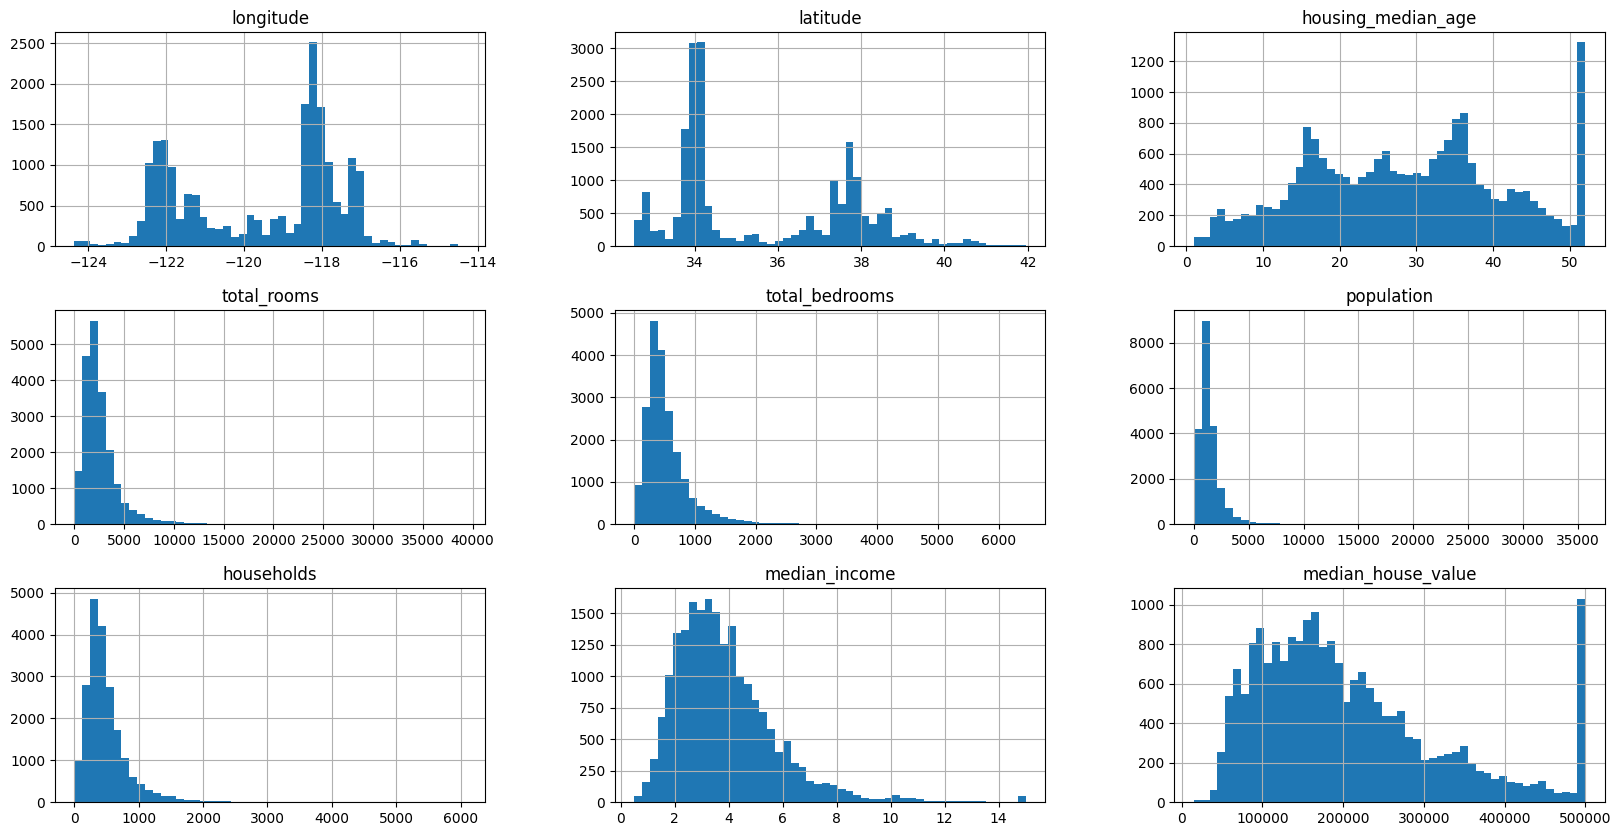

In [8]:
housing_full.hist(bins=50, figsize=(20, 10))
plt.show()

In [9]:
# Shuffle and Split Data into train and test.
def shuffle_and_split_data(data, test_ratio, rng):
    shuffled_indicies = rng.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indicies = shuffled_indicies[:test_set_size]
    train_indicies = shuffled_indicies[test_set_size:]
    return data.iloc[train_indicies], data.iloc[test_indicies]

In [10]:
rng = np.random.default_rng()
train_set, test_set = shuffle_and_split_data(data = housing_full, test_ratio = 0.2, rng = rng)
print("Full         : " , len(housing_full))
print("Train Split  : " , len(train_set))
print("Test Split   : " , len(test_set))

Full         :  20640
Train Split  :  16512
Test Split   :  4128


In [11]:
from zlib import crc32

def is_id_in_test_set (identifier, test_ratio):
    return crc32(np.int64(identifier)) < test_ratio * 2**32

def split_data_with_id_hash (data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio= test_ratio))
    return data.loc[-in_test_set], data.loc[in_test_set]

In [12]:
housing_with_id = housing_full.reset_index() # adds an 'index' column
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, 'index')

In [13]:
housing_with_id["id"] = (housing_full["longitude"] * 1000 + housing_full["latitude"])
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, 'id')

In [14]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(housing_full, test_size = 0.2, random_state = 42)

In [15]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"], bins = [0.,1.5,3.0,4.5,6.,np.inf], labels= [1,2,3,4,5])

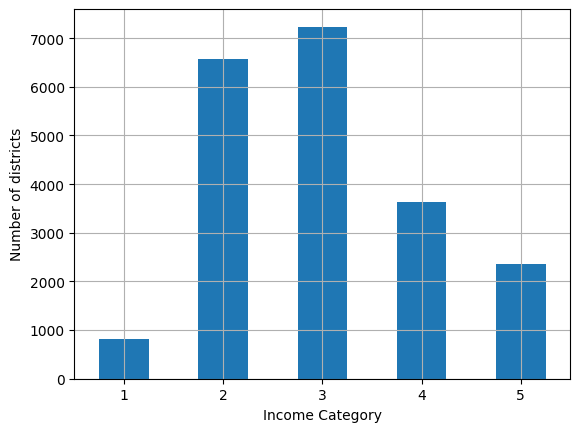

In [16]:
cat_count = housing_full["income_cat"].value_counts().sort_index()
cat_count.plot(kind= 'bar', rot = 0, grid = True)
plt.xlabel("Income Category")
plt.ylabel("Number of districts")
plt.show()

In [17]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits = 10, test_size = 0.2, random_state = 42)
strat_splits = []
for train_index, test_index in splitter.split(housing_full, housing_full["income_cat"]):
    strat_train_set_n = housing_full.iloc[train_index]
    strat_test_set_n = housing_full.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [18]:
strat_train_set, strat_test_set = strat_splits[0]

In [19]:
(strat_test_set["income_cat"].value_counts() / len(strat_test_set)).sort_index()

income_cat
1    0.039971
2    0.318798
3    0.350533
4    0.176357
5    0.114341
Name: count, dtype: float64

In [38]:
strat_train_set, strat_test_set = train_test_split(housing_full, test_size = 0.2, random_state = 42, stratify = housing_full["income_cat"])

(strat_test_set["income_cat"].value_counts() / len(strat_test_set)).sort_index()

strat_train_set

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,458300.0,NEAR BAY,2
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,483800.0,<1H OCEAN,5
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,101700.0,INLAND,2
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,96100.0,INLAND,2
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,361800.0,NEAR OCEAN,3
...,...,...,...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41.0,2237.0,597.0,938.0,523.0,4.7105,500001.0,<1H OCEAN,4
13105,-119.31,36.32,23.0,2945.0,592.0,1419.0,532.0,2.5733,88800.0,INLAND,2
19301,-117.06,32.59,13.0,3920.0,775.0,2814.0,760.0,4.0616,148800.0,NEAR OCEAN,3
19121,-118.40,34.06,37.0,3781.0,873.0,1725.0,838.0,4.1455,500001.0,<1H OCEAN,3


In [39]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis = 1, inplace = True)

In [40]:
housing = strat_train_set.copy()

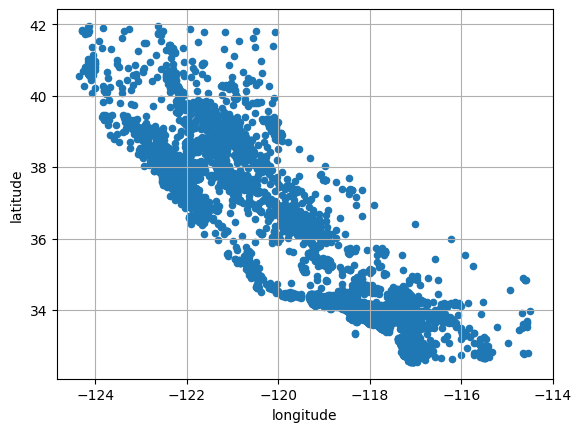

In [42]:
housing.plot(kind = 'scatter', x= 'longitude', y='latitude', grid= True)
plt.show()

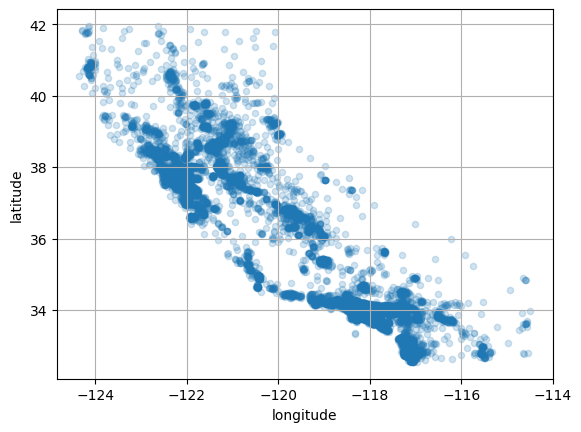

In [43]:
housing.plot(kind = 'scatter', x= 'longitude', y='latitude', grid= True, alpha = 0.2)
plt.show()

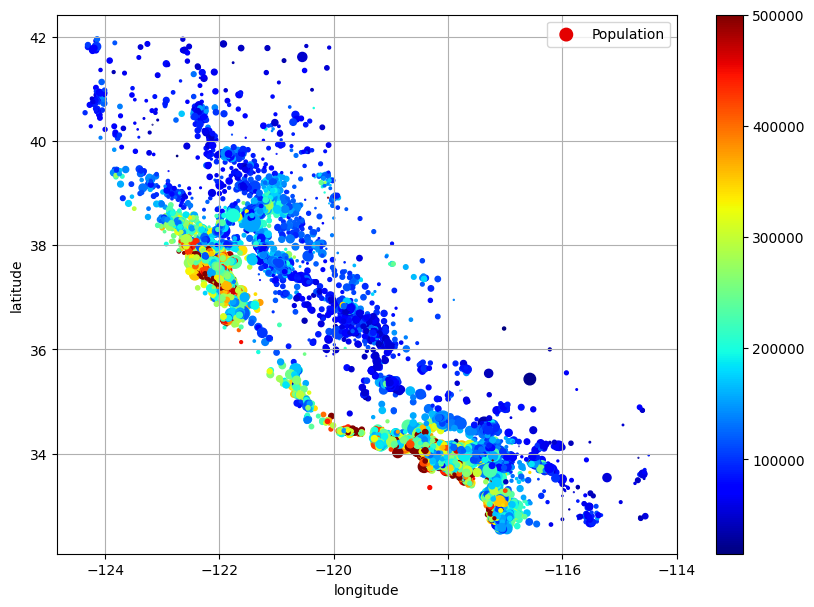

In [53]:
housing.plot(kind = 'scatter', x = 'longitude', y = 'latitude', grid = True,
             s = housing['population'] / 100, label = 'Population',
             c = housing['median_house_value'], cmap = 'jet', colorbar = True,
             legend = True, sharex = False, figsize = (10,  7))
plt.show()

In [61]:
# Look for correlations

corr_matrix = housing.corr(numeric_only= True)

corr_matrix

corr_matrix['median_house_value'].sort_values(ascending = False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

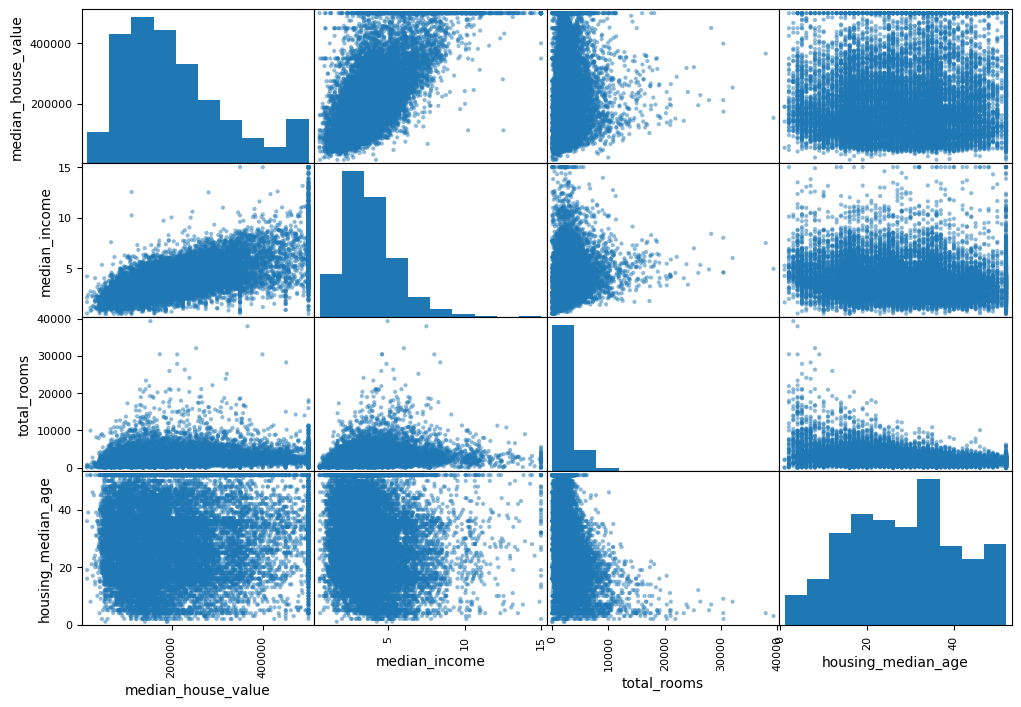

In [63]:
from pandas.plotting import scatter_matrix
attributes = ['median_house_value', 'median_income', 'total_rooms',
       'housing_median_age']
scatter_matrix(housing[attributes], figsize = (12,8))
plt.show()